In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
teams = pd.read_csv("teams_data.csv")
players = pd.read_csv("players-data-updated.csv", encoding="latin1")
matches = pd.read_csv("ipl_matches_data.csv")
balls = pd.read_csv("ball_by_ball_data.csv")

In [3]:
matches.info()
balls.info()
players.info()
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   match_id         1169 non-null   int64  
 1   season_id        1169 non-null   int64  
 2   balls_per_over   1169 non-null   int64  
 3   city             1118 non-null   object 
 4   match_date       1169 non-null   object 
 5   event_name       1169 non-null   object 
 6   match_number     1099 non-null   float64
 7   gender           1169 non-null   object 
 8   match_type       1169 non-null   object 
 9   format           1169 non-null   object 
 10  overs            1169 non-null   int64  
 11  season           1169 non-null   object 
 12  team_type        1169 non-null   object 
 13  venue            1169 non-null   object 
 14  toss_winner      1168 non-null   object 
 15  team1            1169 non-null   object 
 16  team2            1169 non-null   object 
 17  toss_decision 

In [4]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,...,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,...,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,...,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


In [5]:
matches.isnull().sum()
balls.isnull().sum()

season_id                 0
match_id                  0
batter                    0
bowler                    0
non_striker               0
team_batting              0
team_bowling              0
over_number               0
ball_number               0
batter_runs               0
extras                    0
total_runs                0
batsman_type              0
bowler_type               0
player_out           264382
fielders_involved    264382
is_wicket                 0
is_wide_ball              0
is_no_ball                0
is_leg_bye                0
is_bye                    0
is_penalty                0
wide_ball_runs            0
no_ball_runs              0
leg_bye_runs              0
bye_runs                  0
penalty_runs              0
wicket_kind          264382
is_super_over             0
innings                   0
dtype: int64

In [6]:
balls['player_out'] = balls['player_out'].fillna("Not Out")

In [7]:
balls.isnull().sum()

season_id                 0
match_id                  0
batter                    0
bowler                    0
non_striker               0
team_batting              0
team_bowling              0
over_number               0
ball_number               0
batter_runs               0
extras                    0
total_runs                0
batsman_type              0
bowler_type               0
player_out                0
fielders_involved    264382
is_wicket                 0
is_wide_ball              0
is_no_ball                0
is_leg_bye                0
is_bye                    0
is_penalty                0
wide_ball_runs            0
no_ball_runs              0
leg_bye_runs              0
bye_runs                  0
penalty_runs              0
wicket_kind          264382
is_super_over             0
innings                   0
dtype: int64

In [8]:
matches.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result,stage
0,335982,2008,6,Bangalore,18-04-2008,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Royal Challengers Bangalore,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win,NaN
1,1082591,2017,6,Hyderabad,05-04-2017,Indian Premier League,1.0,male,T20,T20,...,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,field,Sunrisers Hyderabad,35.0,NaN,15.0,win,NaN
2,1082592,2017,6,Pune,06-04-2017,Indian Premier League,2.0,male,T20,T20,...,Rising Pune Supergiant,Rising Pune Supergiant,Mumbai Indians,field,Rising Pune Supergiant,NaN,7.0,36.0,win,NaN
3,1082593,2017,6,Rajkot,07-04-2017,Indian Premier League,3.0,male,T20,T20,...,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,field,Kolkata Knight Riders,NaN,10.0,57.0,win,NaN
4,1082594,2017,6,Indore,08-04-2017,Indian Premier League,4.0,male,T20,T20,...,Punjab Kings,Punjab Kings,Rising Pune Supergiant,field,Punjab Kings,NaN,6.0,71.0,win,NaN


In [9]:
matches.isnull().sum()

match_id              0
season_id             0
balls_per_over        0
city                 51
match_date            0
event_name            0
match_number         70
gender                0
match_type            0
format                0
overs                 0
season                0
team_type             0
venue                 0
toss_winner           1
team1                 0
team2                 0
toss_decision         1
match_winner          8
win_by_runs         638
win_by_wickets      554
player_of_match       8
result                0
stage              1165
dtype: int64

In [10]:
balls.head()

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1


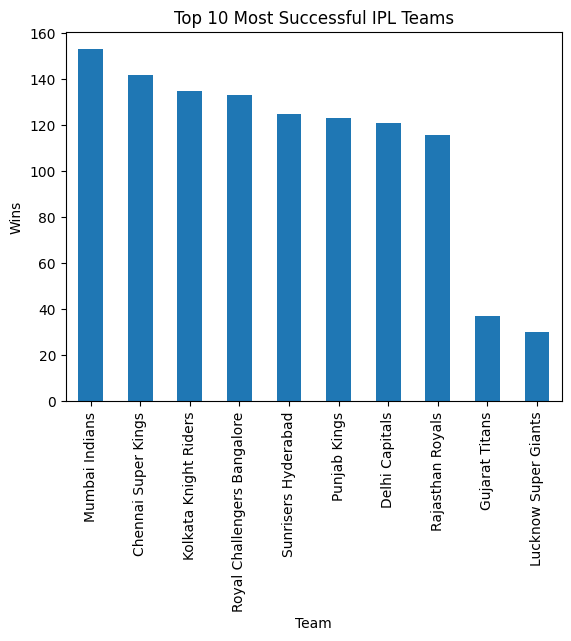

In [11]:
#Most Successful Teams
top_teams = matches['match_winner'].value_counts().head(10)

plt.figure()
top_teams.plot(kind='bar')
plt.title("Top 10 Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()

In [12]:
import pandas as pd
from IPython.display import display, HTML

# Calculate total matches played by each team
total_matches = pd.concat([matches['team1'], matches['team2']]).value_counts().reset_index()
total_matches.columns = ['Team', 'Total Matches']

# Top 10 teams by wins
top_teams = matches['match_winner'].value_counts().head(10).reset_index()
top_teams.columns = ['Team', 'Wins']

# Merge total matches
top_teams = top_teams.merge(total_matches, on='Team', how='left')

# Calculate Win Percentage
top_teams['Win %'] = round((top_teams['Wins'] / top_teams['Total Matches']) * 100, 2)

# Reorder columns
top_teams = top_teams[['Team', 'Total Matches', 'Wins', 'Win %']]

# IPL Colors
BLUE = "#1E3A8A"        # Header Blue
LIGHT_BLUE = "#DBEAFE"  # Row background
LIGHT_GOLD = "#FEF3C7"  # Highlight Top Winner
TEXT_DARK = "#1F2937"

# Function to style table
def style_ipl_table(df):
    styler = (
        df.style
        .set_properties(**{
            "background-color": LIGHT_BLUE,
            "color": TEXT_DARK,
            "text-align": "center",
            "font-size": "12px",
            "border-color": "#93C5FD"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", BLUE),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                    ("text-align", "center")
                ]
            }
        ])
    )

    # Highlight Top Winner (most wins)
    max_wins = df['Wins'].max()
    styler = styler.applymap(
        lambda x: f"background-color: {LIGHT_GOLD}; font-weight: bold" if x == max_wins else "",
        subset=["Wins"]
    )

    return styler

# Apply styling
styled_top_teams = style_ipl_table(top_teams)

# Display with a title
display(HTML("<h3 style='color:#1E3A8A; font-weight:bold'>Top 10 IPL Teams – Most Matches Won</h3>"))
display(styled_top_teams)

C:\Users\jadav\AppData\Local\Temp\ipykernel_15100\2503462226.py:54: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler = styler.applymap(


,Team,Total Matches,Wins,Win %
0,Mumbai Indians,277,153,55.230000
1,Chennai Super Kings,252,142,56.350000
2,Kolkata Knight Riders,265,135,50.940000
3,Royal Challengers Bangalore,271,133,49.080000
4,Sunrisers Hyderabad,271,125,46.130000
5,Punjab Kings,263,123,46.770000
6,Delhi Capitals,266,121,45.490000
7,Rajasthan Royals,235,116,49.360000
8,Gujarat Titans,60,37,61.670000
9,Lucknow Super Giants,58,30,51.720000


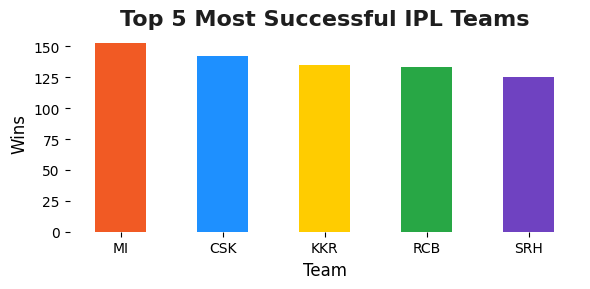

In [13]:
import matplotlib.pyplot as plt

# Top 10 teams
top_teams = matches['match_winner'].value_counts().head(5)

# Map full team names to IPL abbreviations
team_abbrev = {
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Royal Challengers Bangalore': 'RCB',
    'Kolkata Knight Riders': 'KKR',
    'Sunrisers Hyderabad': 'SRH',
    'Delhi Capitals': 'DC',
    'Rajasthan Royals': 'RR',
    'Punjab Kings': 'PBKS',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT'
}

# Replace names with abbreviations
top_teams.index = top_teams.index.map(lambda x: team_abbrev.get(x, x))

# IPL color palette (bright sporty colors)
ipl_colors = [
    '#f15a24', '#1e90ff', '#ffcc00', '#28a745', '#6f42c1',
    '#e83e8c', '#fd7e14', '#20c997', '#007bff', '#ffc107'
]

# Plot
plt.figure(figsize=(6,3))
top_teams.plot(kind='bar', color=ipl_colors[:len(top_teams)])

# Minimalist design
plt.title("Top 5 Most Successful IPL Teams", fontsize=16, fontweight='bold', color='#1e1e1e')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Wins", fontsize=12)
plt.xticks(rotation=0, ha='center')  # Center abbreviations
plt.grid(False)
plt.tight_layout()

# Remove spines for cleaner look
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Show the plot
plt.show()


In [14]:
print(top_teams)

match_winner
MI     153
CSK    142
KKR    135
RCB    133
SRH    125
Name: count, dtype: int64


In [16]:
toss_win_match = matches[matches['toss_winner'] == matches['match_winner']]

percentage = (len(toss_win_match) / len(matches)) * 100
percentage
# Toss winner wins match roughly 51% of the time
# Toss advantage is helpful but not decisive

51.15483319076134

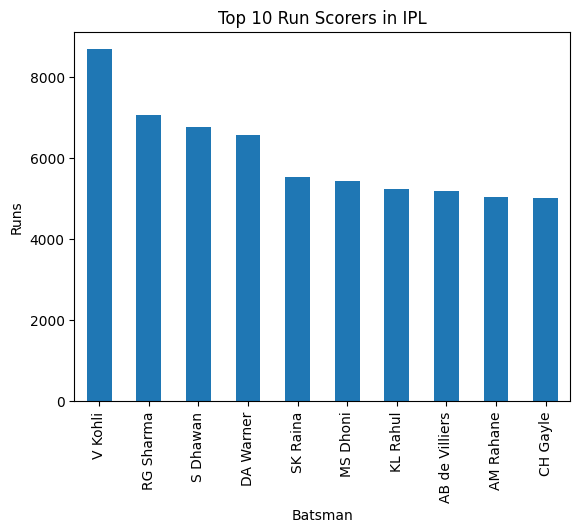

In [17]:
# Top Run Scorers (Ball-by-Ball)
top_batters = balls.groupby('batter')['batter_runs'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_batters.plot(kind='bar')
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.show()

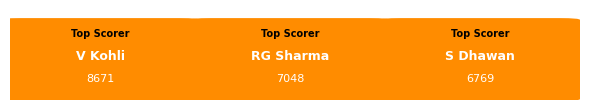

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Top 3 run scorers
top_batters = balls.groupby('batter')['batter_runs'].sum().sort_values(ascending=False).head(3)

# Figure setup (very compact)
fig, ax = plt.subplots(figsize=(6,1.2))  # smaller height

# Box parameters for very small boxes
box_width = 0.18
box_height = 0.9
box_spacing = 0.01  # minimal space

# Loop through top 3 batsmen
for i, (batsman, runs) in enumerate(top_batters.items()):
    x = i * (box_width + box_spacing)
    
    # Draw rectangle box
    box = FancyBboxPatch(
        (x, 0), box_width, box_height,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=0,
        facecolor="#FF8C00",  # orange background
        edgecolor="black"
    )
    ax.add_patch(box)
    
    # Add text
    ax.text(x + box_width/2, 0.7, "Top Scorer", fontsize=7, ha='center', color='black', fontweight='bold')
    ax.text(x + box_width/2, 0.45, batsman, fontsize=9, ha='center', color='white', fontweight='bold')
    ax.text(x + box_width/2, 0.2, f"{runs}", fontsize=8, ha='center', color='white')

# Remove axes
ax.set_xlim(0, len(top_batters)*(box_width + box_spacing))
ax.set_ylim(0,1)
ax.axis('off')
plt.tight_layout()
plt.show()


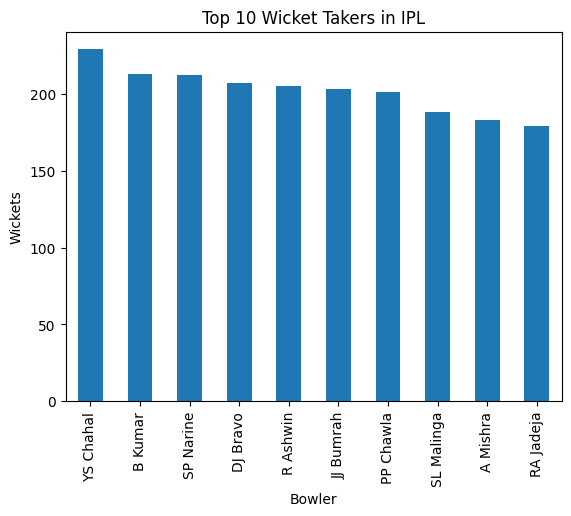

In [19]:
# Best Bowlers (Most Wickets)
wickets = balls[balls['player_out'] != "Not Out"]
top_bowlers = wickets['bowler'].value_counts().head(10)

plt.figure()
top_bowlers.plot(kind='bar')
plt.title("Top 10 Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

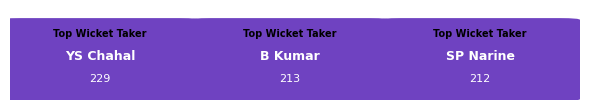

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Filter wickets
wickets = balls[balls['player_out'] != "Not Out"]

# Top 3 bowlers
top_bowlers = wickets['bowler'].value_counts().head(3)

# Figure setup (compact)
fig, ax = plt.subplots(figsize=(6,1.2))

# Box parameters for very small boxes
box_width = 0.18
box_height = 0.9
box_spacing = 0.01  # minimal space

# Loop through top 3 bowlers
for i, (bowler, wickets_count) in enumerate(top_bowlers.items()):
    x = i * (box_width + box_spacing)
    
    # Draw rectangle box with purple background
    box = FancyBboxPatch(
        (x, 0), box_width, box_height,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=0,
        facecolor="#6f42c1",  # Purple
        edgecolor="black"
    )
    ax.add_patch(box)
    
    # Add text inside box
    ax.text(x + box_width/2, 0.7, "Top Wicket Taker", fontsize=7, ha='center', color='black', fontweight='bold')
    ax.text(x + box_width/2, 0.45, bowler, fontsize=9, ha='center', color='white', fontweight='bold')
    ax.text(x + box_width/2, 0.2, f"{wickets_count}", fontsize=8, ha='center', color='white')

# Remove axes
ax.set_xlim(0, len(top_bowlers)*(box_width + box_spacing))
ax.set_ylim(0,1)
ax.axis('off')
plt.tight_layout()
plt.show()


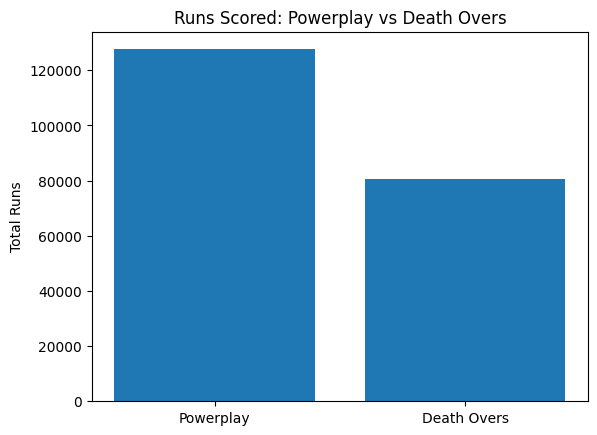

In [21]:


#Powerplay vs Death Overs Scoring
powerplay = balls[balls['over_number'] <= 6]['total_runs'].sum()
death_overs = balls[balls['over_number'] >= 16]['total_runs'].sum()

labels = ['Powerplay', 'Death Overs']
values = [powerplay, death_overs]

plt.figure()
plt.bar(labels, values)
plt.title("Runs Scored: Powerplay vs Death Overs")
plt.ylabel("Total Runs")
plt.show()

In [22]:
print(powerplay)
print(death_overs)

127635
80588


In [23]:
orange_cap = (
    balls.groupby('batter')['batter_runs']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

orange_cap

batter
V Kohli    8671
Name: batter_runs, dtype: int64

In [24]:
season_orange_cap = (
    balls.groupby(['season_id', 'batter'])['batter_runs']
    .sum()
    .reset_index()
    .sort_values(['season_id', 'batter_runs'], ascending=[True, False])
    .groupby('season_id')
    .first()
    .reset_index()
)

season_orange_cap

,season_id,batter,batter_runs
0,2008,SE Marsh,616
1,2009,ML Hayden,572
2,2010,SR Tendulkar,618
3,2011,CH Gayle,608
4,2012,CH Gayle,733
5,2013,MEK Hussey,733
6,2014,RV Uthappa,660
7,2015,DA Warner,562
8,2016,V Kohli,973
9,2017,DA Warner,641


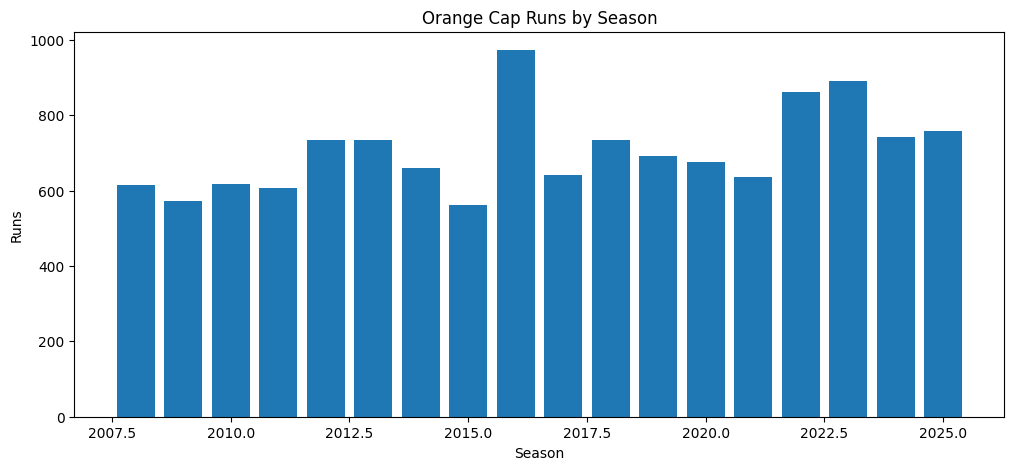

In [25]:
plt.figure(figsize=(12,5))
plt.bar(season_orange_cap['season_id'], season_orange_cap['batter_runs'])
plt.title("Orange Cap Runs by Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.show()


In [26]:
# Consider only valid wickets
wickets = balls[balls['player_out'] != "Not Out"]

season_purple_cap = (
    wickets.groupby(['season_id', 'bowler'])
    .size()
    .reset_index(name='wickets')
    .sort_values(['season_id', 'wickets'], ascending=[True, False])
    .groupby('season_id')
    .first()
    .reset_index()
)

season_purple_cap

,season_id,bowler,wickets
0,2008,Sohail Tanvir,24
1,2009,RP Singh,26
2,2010,PP Ojha,22
3,2011,SL Malinga,30
4,2012,M Morkel,30
5,2013,DJ Bravo,34
6,2014,MM Sharma,26
7,2015,DJ Bravo,28
8,2016,B Kumar,24
9,2017,B Kumar,28


In [27]:
season_fours = (
    balls[balls['batter_runs'] == 4]
    .groupby(['season_id', 'batter'])
    .size()
    .reset_index(name='fours')
    .sort_values(['season_id', 'fours'], ascending=[True, False])
    .groupby('season_id')
    .first()
    .reset_index()
)

season_fours


,season_id,batter,fours
0,2008,G Gambhir,68
1,2009,ML Hayden,60
2,2010,SR Tendulkar,86
3,2011,SR Tendulkar,67
4,2012,AM Rahane,73
5,2013,MEK Hussey,81
6,2014,RV Uthappa,74
7,2015,DA Warner,65
8,2016,DA Warner,88
9,2017,DA Warner,63


In [28]:
season_sixes = (
    balls[balls['batter_runs'] == 6]
    .groupby(['season_id', 'batter'])
    .size()
    .reset_index(name='sixes')
    .sort_values(['season_id', 'sixes'], ascending=[True, False])
    .groupby('season_id')
    .first()
    .reset_index()
)

season_sixes


,season_id,batter,sixes
0,2008,ST Jayasuriya,31
1,2009,AC Gilchrist,29
2,2010,RV Uthappa,27
3,2011,CH Gayle,44
4,2012,CH Gayle,59
5,2013,CH Gayle,52
6,2014,GJ Maxwell,36
7,2015,CH Gayle,38
8,2016,V Kohli,38
9,2017,DA Warner,26


In [29]:
finals = matches[matches['stage'] == 'Final']

ipl_results = finals[['season', 'team1', 'team2', 'match_winner']].copy()

# Determine runner-up
ipl_results['runner_up'] = np.where(
    ipl_results['team1'] == ipl_results['match_winner'],
    ipl_results['team2'],
    ipl_results['team1']
)

ipl_results[['season', 'match_winner', 'runner_up']]


,season,match_winner,runner_up
1166,2025,Royal Challengers Bangalore,Punjab Kings


In [30]:
all_time_fours = (
    balls[balls['batter_runs'] == 4]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(5)
)
all_time_fours

batter
V Kohli      774
S Dhawan     768
DA Warner    663
RG Sharma    640
AM Rahane    515
dtype: int64

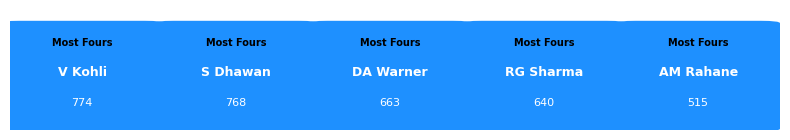

In [31]:
# Top 5 batsmen with most fours
all_time_fours = (
    balls[balls['batter_runs'] == 4]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

# Figure setup (compact row)
fig, ax = plt.subplots(figsize=(8,1.5))  # width 8, height 1.5

# Box parameters
box_width = 0.15
box_height = 0.9
box_spacing = 0.01
fours_color = "#1e90ff"  # Dodger Blue

# Plot Most Fours
for i, (batsman, fours) in enumerate(all_time_fours.items()):
    x = i * (box_width + box_spacing)
    
    # Rectangle box
    box = FancyBboxPatch(
        (x,0), box_width, box_height,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=0,
        facecolor=fours_color,
        edgecolor="black"
    )
    ax.add_patch(box)
    
    # Text inside box
    ax.text(x + box_width/2, 0.7, "Most Fours", fontsize=7, ha='center', color='black', fontweight='bold')
    ax.text(x + box_width/2, 0.45, batsman, fontsize=9, ha='center', color='white', fontweight='bold')
    ax.text(x + box_width/2, 0.2, f"{fours}", fontsize=8, ha='center', color='white')

# Remove axes
ax.set_xlim(0, len(all_time_fours)*(box_width + box_spacing))
ax.set_ylim(0,1)
ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
all_time_sixes = (
    balls[balls['batter_runs'] == 6]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(5)
)
all_time_sixes

batter
CH Gayle          359
RG Sharma         303
V Kohli           292
MS Dhoni          264
AB de Villiers    253
dtype: int64

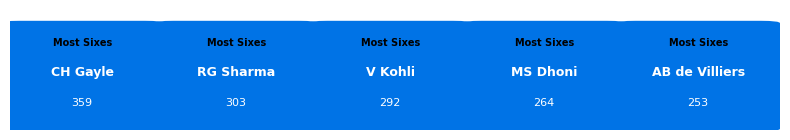

In [33]:
# Top 5 batsmen with most sixes
all_time_sixes = (
    balls[balls['batter_runs'] == 6]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

# Figure setup (compact row)
fig, ax = plt.subplots(figsize=(8,1.5))

# Box parameters
box_width = 0.15
box_height = 0.9
box_spacing = 0.01
sixes_color = "#0073e6"  # Deep Blue

# Plot Most Sixes
for i, (batsman, sixes) in enumerate(all_time_sixes.items()):
    x = i * (box_width + box_spacing)
    
    # Rectangle box
    box = FancyBboxPatch(
        (x,0), box_width, box_height,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=0,
        facecolor=sixes_color,
        edgecolor="black"
    )
    ax.add_patch(box)
    
    # Text inside box
    ax.text(x + box_width/2, 0.7, "Most Sixes", fontsize=7, ha='center', color='black', fontweight='bold')
    ax.text(x + box_width/2, 0.45, batsman, fontsize=9, ha='center', color='white', fontweight='bold')
    ax.text(x + box_width/2, 0.2, f"{sixes}", fontsize=8, ha='center', color='white')

# Remove axes
ax.set_xlim(0, len(all_time_sixes)*(box_width + box_spacing))
ax.set_ylim(0,1)
ax.axis('off')
plt.tight_layout()
plt.show()

In [34]:
# Ensure match_date is datetime
matches['match_date'] = pd.to_datetime(matches['match_date'])

# Step 1: Get final match of each season
final_matches = matches.loc[
    matches.groupby('season')['match_date'].idxmax()
]

# Step 2: Create winner & runner-up
final_matches = final_matches[['season', 'team1', 'team2', 'match_winner']].copy()

final_matches['runner_up'] = np.where(
    final_matches['team1'] == final_matches['match_winner'],
    final_matches['team2'],
    final_matches['team1']
)

# Step 3: Final Result
season_results = final_matches[['season', 'match_winner', 'runner_up']]
season_results


C:\Users\jadav\AppData\Local\Temp\ipykernel_15100\3634128478.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches['match_date'] = pd.to_datetime(matches['match_date'])


,season,match_winner,runner_up
583,2008,Rajasthan Royals,Chennai Super Kings
640,2009,Sunrisers Hyderabad,Royal Challengers Bangalore
700,2010,Chennai Super Kings,Mumbai Indians
773,2011,Chennai Super Kings,Royal Challengers Bangalore
847,2012,Kolkata Knight Riders,Chennai Super Kings
923,2013,Mumbai Indians,Chennai Super Kings
983,2014,Kolkata Knight Riders,Punjab Kings
1042,2015,Mumbai Indians,Chennai Super Kings
1103,2016,Sunrisers Hyderabad,Royal Challengers Bangalore
59,2017,Mumbai Indians,Rising Pune Supergiant


In [35]:
# IPL Colors
BLUE = "#1E3A8A"        # Header Blue
LIGHT_BLUE = "#DBEAFE" # Row / table background
LIGHT_GOLD = "#FEF3C7" # Highlight (Winner)
TEXT_DARK = "#1F2937"
def style_ipl_table(df):
    styler = (
        df.style
        .set_properties(**{
            "background-color": LIGHT_BLUE,
            "color": TEXT_DARK,
            "text-align": "center",
            "font-size": "12px",
            "border-color": "#93C5FD"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", BLUE),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                    ("text-align", "center")
                ]
            }
        ])
    )

    # Highlight Winner
    if "match_winner" in df.columns:
        styler = styler.applymap(
            lambda x: f"background-color: {LIGHT_GOLD}; font-weight: bold",
            subset=["match_winner"]
        )

    # Runner-up (slightly blue)
    if "runner_up" in df.columns:
        styler = styler.applymap(
            lambda x: "background-color: #E0F2FE",
            subset=["runner_up"]
        )

    return styler


In [36]:
styled_season_results = style_ipl_table(season_results)
styled_season_results


C:\Users\jadav\AppData\Local\Temp\ipykernel_15100\3118578318.py:32: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler = styler.applymap(
C:\Users\jadav\AppData\Local\Temp\ipykernel_15100\3118578318.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styler = styler.applymap(


,season,match_winner,runner_up
583,2008,Rajasthan Royals,Chennai Super Kings
640,2009,Sunrisers Hyderabad,Royal Challengers Bangalore
700,2010,Chennai Super Kings,Mumbai Indians
773,2011,Chennai Super Kings,Royal Challengers Bangalore
847,2012,Kolkata Knight Riders,Chennai Super Kings
923,2013,Mumbai Indians,Chennai Super Kings
983,2014,Kolkata Knight Riders,Punjab Kings
1042,2015,Mumbai Indians,Chennai Super Kings
1103,2016,Sunrisers Hyderabad,Royal Challengers Bangalore
59,2017,Mumbai Indians,Rising Pune Supergiant


In [37]:
title_wins = (
    season_results['match_winner']
    .value_counts()
    .reset_index()
)

title_wins.columns = ['team', 'titles_won']

title_wins

,team,titles_won
0,Chennai Super Kings,5
1,Mumbai Indians,5
2,Kolkata Knight Riders,3
3,Sunrisers Hyderabad,2
4,Rajasthan Royals,1
5,Gujarat Titans,1
6,Royal Challengers Bangalore,1


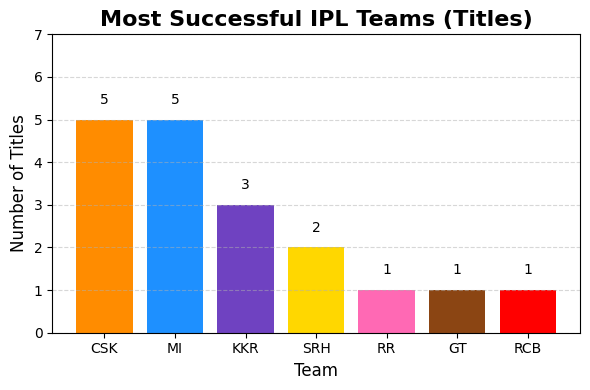

In [38]:
# Map full team names to IPL abbreviations
team_abbrev = {
    'Chennai Super Kings': 'CSK',
    'Mumbai Indians': 'MI',
    'Royal Challengers Bangalore': 'RCB',
    'Kolkata Knight Riders': 'KKR',
    'Sunrisers Hyderabad': 'SRH',
    'Delhi Capitals': 'DC',
    'Rajasthan Royals': 'RR',
    'Punjab Kings': 'PBKS',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT'
}

# Replace team names with abbreviations
title_wins['team_abbr'] = title_wins['team'].map(team_abbrev)

# Define colors for each team
team_colors = {
    'CSK': '#FF8C00',    # Orange
    'MI': '#1E90FF',     # Blue
    'RCB': '#FF0000',    # Red
    'KKR': '#6f42c1',    # Purple
    'SRH': '#FFD700',    # Gold
    'DC': '#228B22',     # Green
    'RR': '#FF69B4',     # Pink
    'PBKS': '#20c997',   # Teal
    'LSG': '#00CED1',    # Cyan
    'GT': '#8B4513'      # Brown
}

# Assign colors
colors = title_wins['team_abbr'].map(team_colors)

# Bar chart
plt.figure(figsize=(6,4))
bars = plt.bar(title_wins['team_abbr'], title_wins['titles_won'], color=colors)

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, int(yval), ha='center', va='bottom', fontsize=10)  # added padding

# Increase y-axis limit slightly to fit text
plt.ylim(0, title_wins['titles_won'].max() + 2)  # add 2 extra units

# Chart styling
plt.title("Most Successful IPL Teams (Titles)", fontsize=16, fontweight='bold')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [39]:
# Count wins per team per season
wins_per_season = (
    matches.groupby(['season', 'match_winner'])
    .size()
    .reset_index(name='wins')
)

# Sort to find highest wins in a single season
most_wins_single_season = wins_per_season.sort_values(
    by='wins',
    ascending=False
).head(10)
most_wins_single_season


,season,match_winner,wins
5,2008,Rajasthan Royals,13
46,2013,Mumbai Indians,13
43,2013,Chennai Super Kings,12
56,2014,Punjab Kings,12
36,2012,Kolkata Knight Riders,12
118,2022,Gujarat Titans,12
103,2020/21,Mumbai Indians,12
79,2017,Mumbai Indians,12
49,2013,Rajasthan Royals,11
19,2010,Mumbai Indians,11
